# GHALogs: Java CI failure exploration

This executed notebook reproduces the metadata workflow from
[D2KLab/gha-dataset](https://github.com/D2KLab/gha-dataset), then extends it with
Java candidate filtering, insight evidence auditing, and selective raw-log analysis.
The authors provide a loader and dataset-metrics notebook; the failure analysis is a project extension.

**Hierarchy:** repository → workflow definition → workflow run → jobs → steps → commands.
A reusable action is a component invoked by a step, not a workflow or a run.
Repeated executions do not create new workflow definitions.

External prerequisites: verified `repositories.json.gz` and `runs.json.gz` from Zenodo
record 10154920, a clone of the pinned upstream source (including examples/parser),
Python packages in `requirements-lock.txt`, and a running MongoDB service.
Set `GHA_DATA_ROOT`, `GHA_SOURCE_ROOT`, `GHA_WORK_ROOT`, `MONGODB_URI`, and optionally
`GHA_DB_NAME` before executing. Original execution used Python 3.12 and MongoDB 7.
Database imports are resumable; no collection deletion or source overwrite is performed.
Raw-log retrieval additionally requires Zenodo network access; annotations reuse the
downloaded metadata rather than requiring the authors' shell-extractor service.

This publication is a copy. The original executed research notebook is immutable.
All code cells in this copy must execute from a fresh kernel, top to bottom.
Raw inputs, log text, caches and review packets stay external to Git. Compact manifests
retain run identifiers, archive locations and integrity hashes for traceability.
Reviewers must obtain external logs/evidence packets; templates alone are not evidence.


In [1]:
import os, sys, json, gzip, csv, re, random, hashlib, struct, zlib, io, tarfile, time
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import pymongo
from pymongo import ReplaceOne
from bson import BSON
from urllib.request import Request, urlopen
from urllib.error import HTTPError

# Set these environment variables to your own external input/work locations.
# Git tracks only notebooks, provenance, compact results and review templates.
BASE = Path(os.getenv('GHA_DATA_ROOT', '../external_data')).resolve()
OUT = Path(os.getenv('GHA_WORK_ROOT', '../external_work')).resolve()
REPO = Path(os.getenv('GHA_SOURCE_ROOT', str(BASE / 'gha-dataset'))).resolve()
MONGODB_URI = os.getenv('MONGODB_URI', 'mongodb://127.0.0.1:27018')
DB_NAME = os.getenv('GHA_DB_NAME', 'gha-scraper')
assert OUT != BASE and OUT != REPO, 'Outputs must be isolated from inputs/source'
for name in ('metadata_audit', 'java_failure_candidates', 'raw_log_evidence',
             'raw', 'normalized', 'windows', 'cache'):
    (OUT/name).mkdir(exist_ok=True, parents=True)
client = pymongo.MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5000)
display(client.admin.command('ping'))
db = client[DB_NAME]
mongo_repositories = db['repositories']; mongo_runs = db['runs']
def save_json(path, obj):
    path.write_text(json.dumps(obj, indent=2, default=str, ensure_ascii=False), encoding='utf-8')
def save_csv(path, rows):
    pd.DataFrame(rows).to_csv(path, index=False)
def jsonl(path, rows):
    with path.open('w', encoding='utf-8') as fd:
        for row in rows: fd.write(json.dumps(row, default=str, ensure_ascii=False)+'\n')
def get_json(url):
    with urlopen(Request(url, headers={'User-Agent':'GHALogs-publication-exploration'}), timeout=60) as response:
        return json.load(response)
print('Python', sys.version.split()[0], 'MongoDB', client.server_info()['version'])
print('External inputs:', BASE, 'External execution outputs:', OUT)

{'ok': 1.0}

Python 3.12.5 MongoDB 7.0.30
External inputs: D:\SJSU MSDA\DATA298A External execution outputs: D:\SJSU MSDA\DATA298A\ghalogs_publication_work\execution


In [2]:
import subprocess, importlib.util
revision=subprocess.check_output(['git','-c','safe.directory='+str(REPO),'-C',str(REPO),'rev-parse','HEAD'],text=True).strip()
save_json(OUT/'metadata_audit'/'upstream_source_revision.json',{'repository':'https://github.com/D2KLab/gha-dataset','revision':revision})
example_run=json.loads((REPO/'examples'/'run.json').read_text(encoding='utf-8'))
example_repo=json.loads((REPO/'examples'/'repository.json').read_text(encoding='utf-8'))
with tarfile.open(REPO/'examples'/'log.tar.gz','r:gz') as example_archive:
    example_members=[{'file':m.name,'bytes':m.size} for m in example_archive.getmembers() if m.isfile()]
    first_job=next(m for m in example_archive.getmembers() if m.isfile() and '/' not in m.name and m.name.endswith('.txt'))
    example_text=example_archive.extractfile(first_job).read().decode('utf-8')
spec=importlib.util.spec_from_file_location('authors_parser',REPO/'src'/'logs'/'parser.py')
authors_parser=importlib.util.module_from_spec(spec); spec.loader.exec_module(authors_parser)
display({'source_revision':revision,'example_run_id':example_run['_id'],
         'example_repo':example_run['repository_name'],'example_conclusion':example_run['metadata']['conclusion'],
         'example_job_files':len(example_run.get('log_insights') or []),'example_archive_members':len(example_members),
         'upstream_parser_context':authors_parser.parse_context(example_text)})
save_csv(OUT/'metadata_audit'/'example_archive_members.csv',example_members)
# Full command re-parsing additionally needs the authors' bash-command-extractor service.
# Existing downloaded command annotations are used in the authors' metrics.

{'source_revision': 'f1cc6685cb58585eb0c619ea01b06c25bb10e131',
 'example_run_id': 'pytables/pytables_.github/workflows/wheels.yml_200_1',
 'example_repo': 'pytables/pytables',
 'example_conclusion': 'success',
 'example_job_files': 18,
 'example_archive_members': 194,
 'upstream_parser_context': {}}

## Metadata integrity, resumable loading and authors-selected metrics

Verify source checksums, preserve IDs and archive provenance, and reproduce the authors’ queries.

In [3]:
record=get_json('https://zenodo.org/api/records/10154920')
files={f['key']:f for f in record['files']}
checks=[]
for name in ('repositories.json.gz','runs.json.gz'):
    path=BASE/name
    h=hashlib.md5()
    with path.open('rb') as f:
        for chunk in iter(lambda:f.read(4*1024*1024),b''): h.update(chunk)
    expected=files[name]['checksum']
    actual='md5:'+h.hexdigest()
    assert path.stat().st_size==files[name]['size'] and actual==expected, (name,actual,expected)
    checks.append({'file':name,'bytes':path.stat().st_size,'checksum':actual,'verified':True})
save_json(OUT/'metadata_audit'/'metadata_input_checksums.json',checks)
display(pd.DataFrame(checks))
def import_jsonl(name, coll):
    state=db['_notebook_imports'].find_one({'_id':name})
    if state and state.get('complete') and coll.count_documents({})==state.get('imported',state.get('count')):
        print('Verified completed import:',name,state); return
    existing={r['_id'] for r in coll.find({}, {'_id':1})}
    n=0; batch=[]; oversized=[]
    with gzip.open(BASE/name,'rt',encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue
            document=json.loads(line)
            n+=1
            if document['_id'] in existing: continue
            bson_size=len(BSON.encode(document))
            if bson_size>16*1024*1024-1024:
                oversized.append({'source_run_id':document['_id'],'source_file':name,'jsonl_record_number':n,'bson_bytes':bson_size,
                    'reason':'MongoDB 16 MB document limit; raw source record preserved'})
                continue
            batch.append(ReplaceOne({'_id':document['_id']},document,upsert=True))
            if len(batch)>=1000:
                coll.bulk_write(batch,ordered=False); batch=[]
                if n%50000==0: print(name,n,flush=True)
    if batch: coll.bulk_write(batch,ordered=False)
    imported=coll.count_documents({})
    assert imported+len(oversized)==n, (imported,len(oversized),n)
    save_json(OUT/'metadata_audit'/(name+'.oversized.json'),oversized)
    db['_notebook_imports'].replace_one({'_id':name},{'_id':name,'complete':True,'source_records':n,'imported':imported,'oversized':len(oversized)},upsert=True)
    print('Imported',name,imported,'of',n,'oversized',len(oversized))
import_jsonl('repositories.json.gz',mongo_repositories)
import_jsonl('runs.json.gz',mongo_runs)
mongo_repositories.create_index('selected')
mongo_runs.create_index('repository_name')
mongo_runs.create_index([('repository_name',1),('workflow_path',1)])
# The upstream insight/archive indexes are not required by its exists/nonempty filters.
# Avoid indexing large nested arrays: retain query semantics without excessive index storage.

,file,bytes,checksum,verified
0,repositories.json.gz,69208463,md5:a44ed2c635348ecc8641f966748e32d2,True
1,runs.json.gz,1063390519,md5:d6c83b48b14351b16766ca1f01290e87,True


Verified completed import: repositories.json.gz {'_id': 'repositories.json.gz', 'complete': True, 'count': 240781}


Verified completed import: runs.json.gz {'_id': 'runs.json.gz', 'complete': True, 'source_records': 580641, 'imported': 580640, 'oversized': 1}


'repository_name_1_workflow_path_1'

In [4]:
languages_repos=list(mongo_repositories.aggregate([
    {'$match':{'selected':True}},
    {'$group':{'_id':'$repo.mainLanguage','nb_repositories':{'$sum':1}}}
]))
lookup=[{'$match':{'selected':True}},
    {'$lookup':{'from':'runs','localField':'_id','foreignField':'repository_name','as':'runs'}},
    {'$unwind':'$runs'},
    {'$match':{'runs.log_insights':{'$exists':True,'$ne':[]}}}]
languages_runs=list(mongo_repositories.aggregate(lookup+[
    {'$group':{'_id':'$repo.mainLanguage','nb_runs':{'$sum':1}}}],allowDiskUse=True))
languages_workflows=list(mongo_repositories.aggregate(lookup+[
    {'$group':{'_id':{'mainLanguage':'$repo.mainLanguage','repository_name':'$runs.repository_name','workflow_path':'$runs.workflow_path'}}},
    {'$group':{'_id':'$_id.mainLanguage','nb_workflows':{'$sum':1}}}],allowDiskUse=True))
language_table=pd.DataFrame(languages_repos).rename(columns={'_id':'language'}).merge(
    pd.DataFrame(languages_runs).rename(columns={'_id':'language'}),on='language',how='left').merge(
    pd.DataFrame(languages_workflows).rename(columns={'_id':'language'}),on='language',how='left').fillna(0)
language_table=language_table.sort_values('nb_repositories',ascending=False)
display(language_table)
language_table.to_csv(OUT/'metadata_audit'/'language_population_metrics.csv',index=False)
metadata_metrics={'all_repository_records':mongo_repositories.count_documents({}),
        'all_run_records':mongo_runs.count_documents({}),
        'authors_selected_repositories':int(language_table.nb_repositories.sum()),
        'authors_selected_runs_with_insights':int(language_table.nb_runs.sum()),
        'authors_selected_workflows_with_insights':int(language_table.nb_workflows.sum())}
metadata_metrics['import_manifest']=list(db['_notebook_imports'].find())
display(metadata_metrics)

,language,nb_repositories,nb_runs,nb_workflows
9,Python,5524,97314,22338
17,TypeScript,4436,84192,18897
15,Go,2948,70381,15767
6,JavaScript,2776,44196,9782
13,C++,2139,40975,9225
7,Java,2074,36665,8338
1,Rust,2022,34897,7975
12,C,1248,23299,5175
4,PHP,1196,20117,4559
11,C#,1098,15881,3788


{'all_repository_records': 240781,
 'all_run_records': 580640,
 'authors_selected_repositories': 28322,
 'authors_selected_runs_with_insights': 513491,
 'authors_selected_workflows_with_insights': 116258,
 'import_manifest': [{'_id': 'repositories.json.gz',
   'complete': True,
   'count': 240781},
  {'_id': 'runs.json.gz',
   'complete': True,
   'source_records': 580641,
   'imported': 580640,
   'oversized': 1}]}

,shell_parser_result,count
0,Success,6016239
1,Parser exception,205807
2,Invalid request,16691


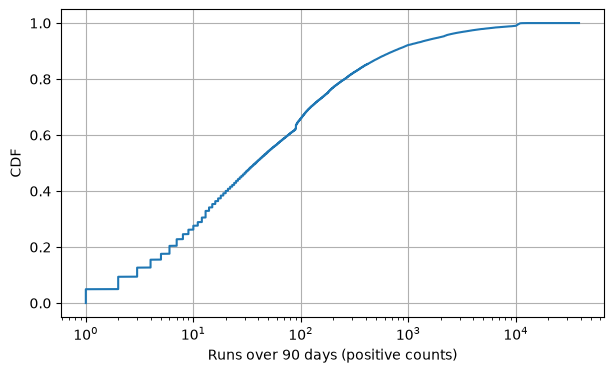

In [5]:
# Authors' shell-parser, download-error, command-annotation and 90-day CDF metrics.
parsing=Counter(); downloads=Counter(); annotation_count=0; command_count=0
for r in mongo_runs.find({}, {'log_insights.steps.type':1,'log_insights.steps.error':1,
                             'log_insights.steps.commands.command':1,'log_insights.steps.commands.annotations':1,
                             'logs_archive.error':1}):
    err=(r.get('logs_archive') or {}).get('error')
    if err: downloads['File name too long' if 'File name too long' in str(err) else str(err)]+=1
    for job in r.get('log_insights') or []:
        for step in job.get('steps') or []:
            if step.get('type')=='shell':
                err=step.get('error')
                parsing[(err.get('error') if isinstance(err,dict) else str(err)) if err else 'Success']+=1
                for command in step.get('commands') or []:
                    command_count+=1; annotation_count+=bool(command.get('annotations'))
metadata_metrics.update(shell_parsing=dict(parsing),log_download_errors=dict(downloads),commands_total=command_count,
    commands_with_annotations=annotation_count,annotation_rate=annotation_count/command_count if command_count else None)
save_json(OUT/'metadata_audit'/'dataset_population_metrics.json',metadata_metrics)
display(pd.DataFrame(parsing.items(),columns=['shell_parser_result','count']))
values=[d['total_runs_90d'] for d in mongo_repositories.find({'total_runs_90d':{'$gt':0}},{'total_runs_90d':1})]
x=np.sort(values); y=np.arange(len(x))/len(x)
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(x,y); ax.set_xscale('log'); ax.set(xlabel='Runs over 90 days (positive counts)',ylabel='CDF'); ax.grid(True)
fig.savefig(OUT/'metadata_audit'/'runs_90d_cdf.png',dpi=150,bbox_inches='tight'); plt.show()

## Java failure population, schema and candidate pilot

Use all Java-main-language records for candidate discovery. Build evidence uses parsed executables and shell invocations, not environment/prose mentions.

In [6]:
java_docs=list(mongo_repositories.find({'repo.mainLanguage':'Java'},{'_id':1,'selected':1,'repo.id':1}))
java_ids=[r['_id'] for r in java_docs]
selected_java_ids={r['_id'] for r in java_docs if r.get('selected') is True}
def meta(r): return r.get('metadata') or {}
def build_signals(r):
    hits=set(); provenance=[]
    for job in r.get('log_insights') or []:
        for step in job.get('steps') or []:
            for cmd in step.get('commands') or []:
                executable=str(cmd.get('command') or '').replace('\\','/').rsplit('/',1)[-1].lower()
                kind='maven' if executable in ('mvn','mvnw','mvn.cmd','mvnw.cmd') else 'gradle' if executable in ('gradle','gradlew','gradle.bat','gradlew.bat') else None
                if kind: hits.add(kind); provenance.append({'system':kind,'command':cmd.get('command'),'job':job.get('file')})
            code=step.get('code') or ''
            for kind,pattern in [('maven',r'(?:^|[\s;&|])(?:\./)?mvnw?(?:\.cmd)?(?=\s|$)'),('gradle',r'(?:^|[\s;&|])(?:\./)?gradlew?(?:\.bat)?(?=\s|$)')]:
                if re.search(pattern,code,re.M): hits.add(kind)
    return '+'.join(sorted(hits)) if hits else 'unknown', provenance
failures=[]; java_conclusions=Counter(); java_builds=Counter(); authors_java_runs=0
for r in mongo_runs.find({'repository_name':{'$in':java_ids}}):
    java_conclusions[meta(r).get('conclusion')]+=1
    system,_=build_signals(r); java_builds[system]+=1
    if r['repository_name'] in selected_java_ids and r.get('log_insights'): authors_java_runs+=1
    if meta(r).get('conclusion')=='failure': failures.append(r)
population=Counter(build_signals(r)[0] for r in failures)
repos=Counter(r['repository_name'] for r in failures)
workflows=Counter((r['repository_name'],r.get('workflow_path')) for r in failures)
months=Counter(str(meta(r).get('created_at',''))[:7] for r in failures)
population_summary={'all_java_repositories':len(java_ids),'authors_selected_java_repositories':len(selected_java_ids),
    'all_java_runs':sum(java_conclusions.values()),'authors_selected_java_runs_with_insights':authors_java_runs,
    'java_conclusions':dict(java_conclusions),'failed_java_runs':len(failures),'failed_build_strata':dict(population),
    'failure_repositories':len(repos),'failure_workflows':len(workflows),'failures_by_month':dict(sorted(months.items())),
    'failed_maven_inclusive':population['maven']+population['gradle+maven'],
    'failed_gradle_inclusive':population['gradle']+population['gradle+maven'],
    'failed_both':population['gradle+maven'],'failed_neither':population['unknown'],
    'failures_per_repository_quantiles':pd.Series(list(repos.values())).quantile([0,.25,.5,.75,.9,1]).to_dict()}
save_json(OUT/'java_failure_candidates'/'java_failure_population.json',population_summary)
save_csv(OUT/'java_failure_candidates'/'failed_runs_by_repository.csv',[{'repo':k,'failures':v} for k,v in repos.most_common()])
save_csv(OUT/'java_failure_candidates'/'failed_runs_by_workflow.csv',[{'repo':k[0],'workflow_path':k[1],'failures':v} for k,v in workflows.most_common()])
display(population_summary)

{'all_java_repositories': 20367,
 'authors_selected_java_repositories': 2074,
 'all_java_runs': 41840,
 'authors_selected_java_runs_with_insights': 36665,
 'java_conclusions': {'success': 34749,
  'failure': 6542,
  'skipped': 343,
  'cancelled': 126,
  'startup_failure': 26,
  'action_required': 54},
 'failed_java_runs': 6542,
 'failed_build_strata': {'maven': 2046,
  'gradle': 1029,
  'unknown': 3403,
  'gradle+maven': 64},
 'failure_repositories': 1234,
 'failure_workflows': 2675,
 'failures_by_month': {'2023-07': 403,
  '2023-08': 549,
  '2023-09': 1330,
  '2023-10': 1691,
  '2023-11': 2569},
 'failed_maven_inclusive': 2110,
 'failed_gradle_inclusive': 1093,
 'failed_both': 64,
 'failed_neither': 3403,
 'failures_per_repository_quantiles': {0.0: 1.0,
  0.25: 2.0,
  0.5: 3.0,
  0.75: 6.0,
  0.9: 10.700000000000045,
  1.0: 218.0}}

In [7]:
# Audit schema across every failed Java run, not a single convenient example.
schema_counts=Counter(); schema_types=defaultdict(Counter); examples={}
def walk(value,path='',depth=0):
    yield path,value
    if depth>=7: return
    if isinstance(value,dict):
        for k,v in value.items():
            if path.endswith(('.env','.with','.languages','.token_permissions')): continue
            yield from walk(v,f'{path}.{k}' if path else k,depth+1)
    elif isinstance(value,list):
        for v in value: yield from walk(v,path+'[]',depth+1)
for r in failures:
    seen=set()
    for path,value in walk(r):
        if not path: continue
        schema_types[path][type(value).__name__]+=1
        if path not in seen: schema_counts[path]+=1; seen.add(path)
        if path not in examples and isinstance(value,(str,int,float,bool)) and not any(k in path for k in ('actor','author','committer')):
            examples[path]=str(value)[:120]
schema_rows=[{'field':p,'runs_present':n,'fraction':n/len(failures),'types':json.dumps(schema_types[p]),'example':examples.get(p,'')} for p,n in sorted(schema_counts.items())]
save_csv(OUT/'java_failure_candidates'/'failed_run_schema_audit.csv',schema_rows)
job_keys=Counter(); step_keys=Counter()
for r in failures:
    for j in r.get('log_insights') or []:
        job_keys.update(j.keys())
        for s in j.get('steps') or []: step_keys.update(s.keys())
display(pd.DataFrame(step_keys.items(),columns=['step_field','occurrences']))
save_json(OUT/'java_failure_candidates'/'parsed_insight_fields.json',{'job_keys':dict(job_keys),'step_keys':dict(step_keys)})

,step_field,occurrences
0,type,161177
1,repository,79047
2,action,79047
3,version,79047
4,sha,79017
5,with,79105
6,env,161177
7,start_date,161177
8,duration_sec,161177
9,code,82072


In [8]:
rng=random.Random(42)
groups=defaultdict(list)
for r in failures: groups[build_signals(r)[0]].append(r)
for records in groups.values():
    records.sort(key=lambda r:str(r['_id'])); rng.shuffle(records)
sample=[]; used=Counter()
for system,quota in [('maven',20),('gradle',20),('gradle+maven',5),('unknown',5)]:
    selected=[]; periods=set()
    pool=groups[system]
    # First pass: prefer months not represented in this stratum and one run per repository.
    for cap in (1,2):
        for month_first in (True,False):
            for r in pool:
                month=str(meta(r).get('created_at',''))[:7]
                if len(selected)>=quota: break
                if r in selected or used[r['repository_name']]>=cap: continue
                if month_first and month in periods: continue
                selected.append(r); used[r['repository_name']]+=1; periods.add(month)
    sample.extend(selected)
assert len(sample)==50 and max(used.values())<=2
jsonl(OUT/'java_failure_candidates'/'stratified_failure_pilot_full_records.jsonl',sample)
def trace(r):
    m=meta(r)
    return {'source_run_id':r['_id'],'repo':r['repository_name'],'github_run_id':m.get('id'),
        'commit_sha':m.get('head_sha'),'workflow_name':m.get('name'),'workflow_path':r.get('workflow_path'),
        'workflow_id':m.get('workflow_id'),'run_attempt':m.get('run_attempt'),'event':m.get('event'),
        'branch':m.get('head_branch'),'conclusion':m.get('conclusion'),'created_at':m.get('created_at'),
        'build_system':build_signals(r)[0],'logs_url':m.get('logs_url'),'archive_path':(r.get('logs_archive') or {}).get('path')}
trace_rows=[trace(r) for r in sample]
save_csv(OUT/'java_failure_candidates'/'stratified_failure_pilot_50.csv',trace_rows)
display(pd.DataFrame(trace_rows)[['repo','build_system','created_at']])

,repo,build_system,created_at
0,wildfly/wildfly,maven,2023-08-06T16:56:13Z
1,apache/ignite,maven,2023-11-10T07:45:54Z
2,datalinkdc/dlink,maven,2023-10-13T09:17:31Z
3,mojohaus/versions-maven-plugin,maven,2023-09-26T19:40:19Z
4,xiaomiwujiecao/kongfuofarchitect,maven,2023-07-27T05:38:00Z
5,arangodb/arangodb-java-driver,maven,2023-10-25T09:34:31Z
6,consulo/consulo,maven,2023-11-10T08:18:52Z
7,nashtech-garage/yas,maven,2023-11-12T13:02:33Z
8,segmentio/analytics-java,maven,2023-11-06T16:43:18Z
9,wso2/product-apim,maven,2023-10-30T11:14:59Z


### Evidence review and valid pilot metrics

An executed command, job name, `surefire` plugin mention, or literal error string inside a script
does not prove the run's cause. Evidence labels require observed output associated with failure.
The audit below records actual fields; absent output produces `unknown`. Human review remains
pending, and the previous reported 100% agreement is withdrawn because labels were copied.

In [9]:
audit=[]; review_packets=[]
for r in sample:
    commands=[]; steps=[]; jobs=[]
    for j in r.get('log_insights') or []:
        jobs.append(j.get('file'))
        for s in j.get('steps') or []:
            steps.append({'job':j.get('file'),'type':s.get('type'),'action':s.get('action'),
                'code':s.get('code'),'start_date':s.get('start_date'),'duration_sec':s.get('duration_sec'),
                'conclusion':s.get('conclusion'),'exit_code':s.get('exit_code')})
            commands.extend(c.get('command') for c in s.get('commands') or [])
    audit.append({**trace(r),'jobs_available':len(jobs),'steps_available':len(steps),'commands_available':len(commands),
        'failing_job_identifiable':False,'failing_step_identifiable':False,'failing_command_identifiable':False,
        'failure_class':'unknown','label_confidence':'low','label_origin':'gha_log_insights_structural_audit',
        'raw_log_needed':True,'manual_review_status':'pending','reason':'No observed error output or reliable step result in insight fields'})
    review_packets.append({'source_run_id':r['_id'],'repo':r['repository_name'],'jobs':jobs,'steps':steps})
save_csv(OUT/'java_failure_candidates'/'insight_evidence_audit.csv',audit)
jsonl(OUT/'java_failure_candidates'/'review_packets.jsonl',review_packets)
manual=[{**trace(r),'reviewer':'','review_status':'pending','manual_failure_class':'',
    'evidence_text':'','agreement':'','notes':''} for r in sample]
if not (OUT/'java_failure_candidates'/'insight_review_template.csv').exists(): save_csv(OUT/'java_failure_candidates'/'insight_review_template.csv',manual)
insight_metrics={'n':len(sample),'unique_repositories':len(used),'sample_strata':dict(Counter(x['build_system'] for x in audit)),
    'failing_job_identification_rate':0,'failing_step_identification_rate':0,'failing_command_identification_rate':0,
    'high_confidence_label_rate':0,'unknown_rate':1,'raw_log_needed_rate':1,
    'independent_human_agreement':None,'human_review_status':'pending',
    'interpretation':'Exploratory purposive pilot; rates are structural audit results, not validated population accuracy estimates',
    'decision':'C: insight structure supports candidate filtering, not failure-cause labels'}
save_json(OUT/'java_failure_candidates'/'insight_pilot_metrics.json',insight_metrics); display(insight_metrics)

{'n': 50,
 'unique_repositories': 50,
 'sample_strata': {'maven': 20, 'gradle': 20, 'gradle+maven': 5, 'unknown': 5},
 'failing_job_identification_rate': 0,
 'failing_step_identification_rate': 0,
 'failing_command_identification_rate': 0,
 'high_confidence_label_rate': 0,
 'unknown_rate': 1,
 'raw_log_needed_rate': 1,
 'independent_human_agreement': None,
 'human_review_status': 'pending',
 'interpretation': 'Exploratory purposive pilot; rates are structural audit results, not validated population accuracy estimates',
 'decision': 'C: insight structure supports candidate filtering, not failure-cause labels'}

## Selective raw-log acquisition through ZIP64 ranges

Retrieve only the archive tail, index and selected members. Validate byte ranges, size and CRC32. Limits: 200 MB index, 20 MB per member, 100 MB total compressed members.

In [10]:
targets=[]
for system,quota in [('maven',4),('gradle',4),('gradle+maven',2),('unknown',2)]:
    targets.extend([r for r in sample if build_signals(r)[0]==system][:quota])
assert len(targets)==12
save_csv(OUT/'raw_log_evidence'/'raw_log_pilot_targets_12.csv',[{**trace(r),'selection_reason':'Unknown structural evidence; diverse build systems/repositories; no high-confidence insight controls available'} for r in targets])
ARCHIVE_URL=files['github_run_logs.zip']['links']['self']
ARCHIVE_SIZE=files['github_run_logs.zip']['size']
network_bytes=0
def byte_range(start,end,limit):
    global network_bytes
    assert 0<=start<=end<ARCHIVE_SIZE and end-start+1<=limit
    req=Request(ARCHIVE_URL+'?range_start='+str(start),headers={'Range':f'bytes={start}-{end}','User-Agent':'GHALogs-notebook-research'})
    with urlopen(req,timeout=90) as response:
        expected=f'bytes {start}-{end}/{ARCHIVE_SIZE}'
        if response.status!=206 or response.headers.get('Content-Range')!=expected:
            raise RuntimeError('Selective retrieval refused: '+str(response.status)+' '+str(response.headers.get('Content-Range')))
        body=response.read(limit+1)
    network_bytes+=len(body)
    if len(body)!=end-start+1: raise RuntimeError('Incomplete/oversized range')
    return body
tail=byte_range(ARCHIVE_SIZE-131072,ARCHIVE_SIZE-1,131072)
eocd=tail.rfind(b'PK\x05\x06'); assert eocd>=0
locator=tail.rfind(b'PK\x06\x07'); assert locator>=0
zip64_offset=struct.unpack_from('<Q',tail,locator+8)[0]
record_offset=zip64_offset-(ARCHIVE_SIZE-len(tail))
z64=struct.unpack_from('<4sQ2H2L4Q',tail,record_offset)
entries,cd_size,cd_offset=z64[7],z64[8],z64[9]
assert cd_size<=200*1024*1024
assessment={'archive_bytes':ARCHIVE_SIZE,'range_supported':True,'zip64_entries':entries,
    'central_directory_bytes':cd_size,'central_directory_offset':cd_offset,'target_runs':len(targets)}
save_json(OUT/'raw_log_evidence'/'selective_retrieval_assessment.json',assessment); display(assessment)
cache=OUT/'cache'/'central_directory.bin'
if cache.exists() and cache.stat().st_size==cd_size:
    directory=cache.read_bytes()
else:
    chunks=[]
    for start in range(cd_offset,cd_offset+cd_size,8*1024*1024):
        end=min(start+8*1024*1024-1,cd_offset+cd_size-1)
        chunks.append(byte_range(start,end,8*1024*1024)); print('Index bytes',sum(map(len,chunks)),flush=True)
    directory=b''.join(chunks); cache.write_bytes(directory)

{'archive_bytes': 142292965496,
 'range_supported': True,
 'zip64_entries': 669929,
 'central_directory_bytes': 100089342,
 'central_directory_offset': 142192876056,
 'target_runs': 12}

In [11]:
desired={r['_id']:(r.get('logs_archive') or {}).get('path','').replace('\\','/') for r in targets}
members={}; pos=0; parsed=0
while pos<len(directory):
    assert directory[pos:pos+4]==b'PK\x01\x02'
    h=struct.unpack_from('<4s6H3L5H2L',directory,pos)
    flag,method,crc,compressed,uncompressed=h[3],h[4],h[7],h[8],h[9]
    namelen,extralen,commentlen,offset=h[10],h[11],h[12],h[16]
    name=directory[pos+46:pos+46+namelen].decode('utf-8' if flag&0x800 else 'cp437')
    extra=directory[pos+46+namelen:pos+46+namelen+extralen]; cursor=0
    while cursor+4<=len(extra):
        kind,size=struct.unpack_from('<HH',extra,cursor); payload=extra[cursor+4:cursor+4+size]; cursor+=4+size
        if kind==1:
            idx=0
            if uncompressed==0xffffffff: uncompressed=struct.unpack_from('<Q',payload,idx)[0]; idx+=8
            if compressed==0xffffffff: compressed=struct.unpack_from('<Q',payload,idx)[0]; idx+=8
            if offset==0xffffffff: offset=struct.unpack_from('<Q',payload,idx)[0]
    for source_id,path in desired.items():
        suffix=path.split('/logs/',1)[-1] if '/logs/' in path else path.lstrip('/')
        if suffix and (name==suffix or name.endswith('/'+suffix)):
            if source_id in members: raise RuntimeError('Ambiguous archive mapping '+source_id)
            members[source_id]={'member':name,'method':method,'crc32':crc,'compressed':compressed,'uncompressed':uncompressed,'offset':offset}
    parsed+=1; pos+=46+namelen+extralen+commentlen
assert parsed==entries
save_json(OUT/'raw_log_evidence'/'selected_archive_member_index.json',members)
display(pd.DataFrame.from_dict(members,orient='index'))

,member,method,crc32,compressed,uncompressed,offset
datalinkdc/dlink_.github/workflows/backend.yaml_3120_1,logs/DataLinkDC/dinky/Backend_2fb4/3120-1.tar.gz,0,3600675589,1075875,1075875,5911428687
onesignal/onesignal-android-sdk_.github/workflows/ci.yml_186_1,logs/OneSignal/OneSignal-Android-SDK/Test_532e...,0,2326754871,23165,23165,16268512418
universite-gustave-eiffel/noisemodelling_.github/workflows/CI.yml_612_1,logs/Universite-Gustave-Eiffel/NoiseModelling/...,0,202411960,174949,174949,25727449356
apache/flink-ml_.github/workflows/java-tests.yml_834_1,logs/apache/flink-ml/Java_Tests_1ebe/834-1.tar.gz,0,2283902411,4964525,4964525,35772310126
apache/ignite_.github/workflows/sonar-pr-from-fork.yml_1807_1,logs/apache/ignite/Sonar_Quality_Pull_Request_...,0,3655157471,198024,198024,35898348576
firebase/firebase-android-sdk_.github/workflows/semver-check.yml_139_1,logs/firebase/firebase-android-sdk/Semver_Chec...,0,273393485,34399,34399,64760878692
googlemaps/android-samples_.github/workflows/generate-v3.yml_7165_1,logs/googlemaps-samples/android-samples/Genera...,0,1055250533,1275395,1275395,71098200696
liferay/liferay-blade-samples_.github/workflows/verify.yml_130_1,logs/liferay/liferay-blade-samples/SF_and_Buil...,0,3085415523,1998851,1998851,87473780265
mojohaus/versions-maven-plugin_.github/workflows/maven.yml_1503_1,logs/mojohaus/versions/GitHub_CI_3fd9/1503-1.t...,0,2060545048,146893,146893,94940159000
spring-projects/spring-statemachine_.github/workflows/pr.yml_51_1,logs/spring-projects/spring-statemachine/PR_c3...,0,491489373,31684,31684,126970547786


In [12]:
manifest=[]; member_downloaded=0
for r in targets:
    source=r['_id']; t=trace(r); info=members.get(source)
    local=OUT/'raw'/(hashlib.sha256(source.encode()).hexdigest()[:20]+'.tar.gz')
    try:
        if not info: raise RuntimeError('No unique indexed archive member for metadata path')
        if max(info['compressed'],info['uncompressed'])>20*1024*1024: raise RuntimeError('Member exceeds 20 MB budget')
        if local.exists():
            payload=local.read_bytes(); method='cached_verified_member'
        else:
            if member_downloaded+info['compressed']>100*1024*1024: raise RuntimeError('Total member budget exceeded')
            header=byte_range(info['offset'],info['offset']+29,30)
            fields=struct.unpack('<4s5H3L2H',header); assert fields[0]==b'PK\x03\x04'
            if fields[2]!=info['method'] or fields[1]&1: raise RuntimeError('Method mismatch or encrypted member')
            start=info['offset']+30+fields[-2]+fields[-1]
            encoded=byte_range(start,start+info['compressed']-1,20*1024*1024)
            payload=encoded if info['method']==0 else zlib.decompress(encoded,-15) if info['method']==8 else None
            if payload is None: raise RuntimeError('Unsupported ZIP compression')
            member_downloaded+=len(encoded); method='zip64_http_range'
        if len(payload)!=info['uncompressed'] or zlib.crc32(payload)&0xffffffff!=info['crc32']:
            raise RuntimeError('Member size/CRC32 failed')
        if not local.exists(): local.write_bytes(payload)
        manifest.append({**t,'local_path':str(local),'member':info['member'],'bytes':len(payload),
            'sha256':hashlib.sha256(payload).hexdigest(),'retrieval_method':method,'retrieval_status':'success'})
    except Exception as exc:
        manifest.append({**t,'local_path':'','bytes':0,'retrieval_status':'failed','notes':str(exc)})
save_csv(OUT/'raw_log_evidence'/'retrieved_archive_integrity.csv',manifest)
display(pd.DataFrame(manifest)[['repo','retrieval_status','bytes']])

,repo,retrieval_status,bytes
0,wildfly/wildfly,success,432309
1,apache/ignite,success,198024
2,datalinkdc/dlink,success,1075875
3,mojohaus/versions-maven-plugin,success,146893
4,firebase/firebase-android-sdk,success,34399
5,googlemaps/android-samples,success,1275395
6,onesignal/onesignal-android-sdk,success,23165
7,spring-projects/spring-statemachine,success,31684
8,universite-gustave-eiffel/noisemodelling,success,174949
9,liferay/liferay-blade-samples,success,1998851


### Normalize separately, find specific anchors, compare windows

Raw tar.gz archives are immutable. Text decoding replaces invalid UTF-8 while counting replacements.
ANSI removal preserves timestamps, ordering, group boundaries, whitespace and stack traces.
Failure labels below are exploratory raw-output heuristics awaiting independent review. Specific
failure messages outrank generic errors; a command or plugin name alone cannot assign a class.

In [13]:
ANSI=re.compile(r'\x1b\[[0-?]*[ -/]*[@-~]')
RULES=[
 ('dependency',r'Could not resolve dependencies|Could not find artifact|Could not resolve all (?:files|dependencies)|Could not resolve [^\n]+',5),
 ('compilation',r'COMPILATION ERROR|cannot find symbol|Compilation failed|error: (?:package .* does not exist|incompatible types)',5),
 ('test',r'There (?:are|were) (?:failing tests|test failures)|Tests run:.*(?:Failures: [1-9]|Errors: [1-9])|AssertionError|:test FAILED',5),
 ('configuration',r'JAVA_HOME is not (?:set|defined)|Could not find or load main class|invalid target release|Unsupported class file major version',4),
 ('infrastructure',r'No space left on device|Network is unreachable|Connection refused|Connection timed out|The runner has lost communication',4),
 ('unknown',r'BUILD FAILURE|FAILURE: Build failed|Execution failed for task|Failed to execute goal|##\[error\]|Process completed with exit code',1)]
normalization=[]; comparisons=[]; windows=[]; review_views=[]
for entry in manifest:
    if entry['retrieval_status']!='success': continue
    source=entry['source_run_id']; prefix=Path(entry['local_path']).stem.replace('.tar','')
    job_texts=[]; total_text=0
    with tarfile.open(entry['local_path'],'r:gz') as archive:
        for member in archive.getmembers():
            if not member.isfile() or '/' in member.name or not member.name.endswith('.txt'): continue
            if member.size>30*1024*1024 or total_text+member.size>100*1024*1024: continue
            data=archive.extractfile(member).read(); total_text+=len(data)
            decoded=data.decode('utf-8',errors='replace'); normalized=ANSI.sub('',decoded)
            jobid=hashlib.sha256(member.name.encode()).hexdigest()[:12]
            name=prefix+'_'+jobid+'.txt'; path=OUT/'normalized'/name
            path.write_text(normalized,encoding='utf-8')
            lines=normalized.splitlines(); job_texts.append((member.name,lines,path))
            normalization.append({'source_run_id':source,'job_file':member.name,'normalized_path':str(path),
                'raw_text_bytes':len(data),'normalized_bytes':len(normalized.encode()),'lines':len(lines),
                'replacement_characters':decoded.count('\ufffd'),'ansi_sequences':len(ANSI.findall(decoded)),
                'group_markers':normalized.count('##[group]'),'timestamp_lines':sum(bool(re.match(r'^\d{4}-\d{2}-\d{2}T',s)) for s in lines)})
    hits=[]
    for job,lines,path in job_texts:
        for i,line in enumerate(lines):
            # Skip command-display lines; literal strings in shell code are not observed errors.
            if '##[group]Run ' in line: continue
            for cls,pattern,rank in RULES:
                if re.search(pattern,line,re.I): hits.append((rank,cls,job,i,line,path,lines))
    specific=[h for h in hits if h[1]!='unknown']
    chosen=max(specific or hits,key=lambda h:(h[0],-h[3])) if hits else None
    cls=chosen[1] if chosen else 'unknown'; conf='medium' if cls!='unknown' else 'low'
    selected_window=None
    if chosen:
        rank,_,job,idx,line,path,lines=chosen
        for radius in (20,50,100):
            start=max(0,idx-radius); end=min(len(lines),idx+radius+1)
            # Extend through any contiguous exception/stack-trace tail.
            while end<len(lines) and end-start<500 and re.search(r'(?:\bat [\w.$]+\(|Caused by:|Suppressed:|\.\.\. \d+ more)',lines[end]): end+=1
            snippet='\n'.join(lines[start:end]); window_path=OUT/'windows'/(prefix+'_'+str(radius)+'.txt')
            window_path.write_text(snippet,encoding='utf-8')
            windows.append({'source_run_id':source,'job_file':job,'radius':radius,'start_line':start+1,'end_line':end,
                'characters':len(snippet),'window_path':str(window_path),'root_cause_sufficiency':'pending_review',
                'important_context_lost':'pending_review','anchor':line[:500]})
            if radius==50: selected_window=snippet
    comparisons.append({**{k:entry.get(k) for k in ('source_run_id','repo','build_system','commit_sha','workflow_name')},
        'insight_class':'unknown','insight_confidence':'low','raw_class':cls,'raw_confidence':conf,
        'label_changed':cls!='unknown','label_origin':'gha_raw_log_heuristic','strongest_evidence':chosen[4][:500] if chosen else '',
        'failing_job_candidate':chosen[2] if chosen else '', 'human_review_status':'pending'})
    review_views.append({'source_run_id':source,'repo':entry['repo'],'class':cls,'anchor':chosen[4] if chosen else '',
        'window':selected_window or 'No error anchor detected'})
save_csv(OUT/'raw_log_evidence'/'job_log_normalization_manifest.csv',normalization)
save_csv(OUT/'raw_log_evidence'/'failure_window_experiment.csv',windows)
save_csv(OUT/'raw_log_evidence'/'insight_vs_raw_failure_labels.csv',comparisons)
jsonl(OUT/'raw_log_evidence'/'raw_review_packets.jsonl',review_views)
display(pd.DataFrame(comparisons)[['repo','raw_class','strongest_evidence']])

,repo,raw_class,strongest_evidence
0,wildfly/wildfly,unknown,2023-08-07T16:00:56.2941196Z [INFO] BUILD FAILURE
1,apache/ignite,unknown,2023-11-10T08:19:22.2569263Z [INFO] BUILD FAILURE
2,datalinkdc/dlink,compilation,2023-10-13T09:20:23.2981294Z [ERROR] COMPILATI...
3,mojohaus/versions-maven-plugin,unknown,2023-09-26T19:55:11.5934644Z [INFO] BUILD FAILURE
4,firebase/firebase-android-sdk,unknown,2023-11-09T15:02:58.4208839Z FAILURE: Build fa...
5,googlemaps/android-samples,dependency,2023-10-11T13:22:43.9673082Z > Could not resol...
6,onesignal/onesignal-android-sdk,unknown,2023-09-25T17:58:08.5623778Z FAILURE: Build fa...
7,spring-projects/spring-statemachine,test,2023-08-29T07:37:13.8693419Z java.lang.Ass...
8,universite-gustave-eiffel/noisemodelling,dependency,2023-09-05T12:53:14.8286555Z > Could not resol...
9,liferay/liferay-blade-samples,unknown,2023-10-16T19:26:19.9662080Z FAILURE: Build fa...


In [14]:
success=[m for m in manifest if m['retrieval_status']=='success']; n=len(comparisons)
raw_metrics={'targets':len(targets),'retrieved':len(success),'member_payload_bytes':sum(m['bytes'] for m in success),
    'network_bytes_this_execution':network_bytes,'cached_index_bytes':cd_size,
    'median_raw_archive_bytes':float(np.median([m['bytes'] for m in success])) if success else None,
    'heuristic_unknowns_resolved':sum(c['raw_class']!='unknown' for c in comparisons),
    'heuristic_unknowns_remaining':sum(c['raw_class']=='unknown' for c in comparisons),
    'raw_heuristic_class_counts':dict(Counter(c['raw_class'] for c in comparisons)),
    'human_confirmed_labels':None,'human_label_changes':None,'error_window_success_rate':None,
    'independent_review_status':'pending','denominator':n,
    'recommendation':'Raw-log evidence required for labels in this pilot; use metadata/insights to select candidates, then raw windows plus review. Accuracy remains unvalidated.'}
save_json(OUT/'raw_log_evidence'/'raw_log_pilot_metrics.json',raw_metrics); display(raw_metrics)
if not (OUT/'raw_log_evidence'/'raw_log_review_template.csv').exists(): save_csv(OUT/'raw_log_evidence'/'raw_log_review_template.csv',[
    {'source_run_id':c['source_run_id'],'repo':c['repo'],'reviewer':'','human_failure_class':'',
     'human_confidence':'','evidence':'','chosen_window_radius':'','window_sufficient':'','notes':''} for c in comparisons])

{'targets': 12,
 'retrieved': 11,
 'member_payload_bytes': 10356069,
 'network_bytes_this_execution': 131072,
 'cached_index_bytes': 100089342,
 'median_raw_archive_bytes': 198024.0,
 'heuristic_unknowns_resolved': 4,
 'heuristic_unknowns_remaining': 7,
 'raw_heuristic_class_counts': {'unknown': 7,
  'compilation': 1,
  'dependency': 2,
  'test': 1},
 'human_confirmed_labels': None,
 'human_label_changes': None,
 'error_window_success_rate': None,
 'independent_review_status': 'pending',
 'denominator': 11,
 'recommendation': 'Raw-log evidence required for labels in this pilot; use metadata/insights to select candidates, then raw windows plus review. Accuracy remains unvalidated.'}

## Raw-log feature extraction and shared schema

Pattern detection rates are separate from validated label quality. Independent review remains pending.

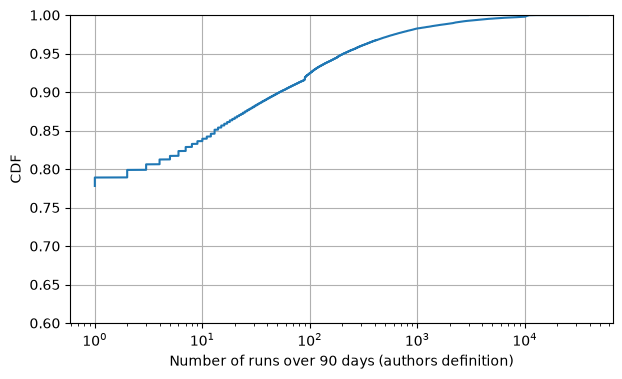

,source_run_id,repo,exception_types,candidate_test_names,stack_trace_lines,exit_codes,candidate_failing_commands,command_groups_present,normalization_bytes,test_name_review_status,failing_command_review_status
0,apache/flink-ml_.github/workflows/java-tests.y...,apache/flink-ml,"[""SerializedCheckpointException"", ""handleCheck...",[],5763,[],"[""./tools/ci/java_test_controller.sh \""tests\""...",36,26985691,pending,pending
1,apache/ignite_.github/workflows/sonar-pr-from-...,apache/ignite,"[""MojoExecutionException"", ""java.lang.Unsuppor...",[],186,"[""1""]","[""./mvnw org.sonarsource.scanner.maven:sonar-m...",7,811563,pending,pending
2,datalinkdc/dlink_.github/workflows/backend.yam...,datalinkdc/dlink,"[""MojoFailureException"", ""javax.xml.bind.DataB...",[],0,"[""1"", ""1""]","[""./mvnw -B clean install \\""]",59,4023738,pending,pending
3,firebase/firebase-android-sdk_.github/workflow...,firebase/firebase-android-sdk,"[""java.lang.NullPointerException""]",[],0,"[""1""]","[""./gradlew semverCheckForRelease""]",2,97345,pending,pending
4,googlemaps/android-samples_.github/workflows/g...,googlemaps/android-samples,[],[],0,"[""1""]","[""cd ApiDemos/java""]",4,16574530,pending,pending
5,liferay/liferay-blade-samples_.github/workflow...,liferay/liferay-blade-samples,"[""NoAlertPresentException"", ""NoSuchBarExceptio...",[],2,"[""1""]","[""cd liferay-workspace""]",44,8950454,pending,pending
6,mojohaus/versions-maven-plugin_.github/workflo...,mojohaus/versions-maven-plugin,"[""MojoFailureException"", ""org.apache.maven.lif...",[],0,"[""1""]","[""./mvnw --errors --batch-mode --show-version ...",6,602302,pending,pending
7,onesignal/onesignal-android-sdk_.github/workfl...,onesignal/onesignal-android-sdk,[],[],0,"[""1""]","[""./gradlew ktlintCheck --console=plain""]",6,58415,pending,pending
8,spring-projects/spring-statemachine_.github/wo...,spring-projects/spring-statemachine,"[""java.lang.AssertionError""]",[],0,"[""1""]","[""./gradlew clean build""]",5,98784,pending,pending
9,universite-gustave-eiffel/noisemodelling_.gith...,universite-gustave-eiffel/noisemodelling,"[""DataLengthException"", ""DbKeyStoreSocketFacto...",[],246,"[""1""]","[""mvn test install -B""]",4,753934,pending,pending


{'targets': 12,
 'retrieved': 11,
 'member_payload_bytes': 10356069,
 'network_bytes_this_execution': 131072,
 'cached_index_bytes': 100089342,
 'median_raw_archive_bytes': 198024.0,
 'heuristic_unknowns_resolved': 4,
 'heuristic_unknowns_remaining': 7,
 'raw_heuristic_class_counts': {'unknown': 7,
  'compilation': 1,
  'dependency': 2,
  'test': 1},
 'human_confirmed_labels': None,
 'human_label_changes': None,
 'error_window_success_rate': None,
 'independent_review_status': 'pending',
 'denominator': 11,
 'recommendation': 'Raw-log evidence required for labels in this pilot; use metadata/insights to select candidates, then raw windows plus review. Accuracy remains unvalidated.',
 'exception_pattern_detection_rate': 0.8181818181818182,
 'stack_trace_pattern_detection_rate': 0.45454545454545453,
 'candidate_test_name_detection_rate': 0.0,
 'candidate_failing_command_detection_rate': 1.0,
 'feature_interpretation': 'Pattern detection only; exception names can occur in handled errors; t

{'completed_insight_reviews': 0,
 'insight_sample_size': 50,
 'agreement_rate_on_reviewed_cases': None,
 'raw_independent_review_status': 'pending'}

In [15]:
# Additional raw-log features and schema compatibility, reproducible from saved manifests.
import json, re
from pathlib import Path
import pandas as pd
from IPython.display import display
import pymongo
import numpy as np
import matplotlib.pyplot as plt
# Authors' exact CDF denominator includes zero-run repositories. A log axis only displays x>0.
ext_client=pymongo.MongoClient(MONGODB_URI,serverSelectionTimeoutMS=5000)
ext_counts=[r['total_runs_90d'] for r in ext_client[DB_NAME]['repositories'].find(
    {'total_runs_90d':{'$gte':0}},{'total_runs_90d':1})]
ext_x=np.sort(ext_counts); ext_y=np.arange(len(ext_x))/float(len(ext_x)); ext_positive=ext_x>0
ext_fig,ext_ax=plt.subplots(figsize=(7,4))
ext_ax.plot(ext_x[ext_positive],ext_y[ext_positive]); ext_ax.set_xscale('log'); ext_ax.set_ylim(.6,1)
ext_ax.set(xlabel='Number of runs over 90 days (authors definition)',ylabel='CDF'); ext_ax.grid(True)
ext_fig.savefig(OUT/'metadata_audit'/'authors_runs_90d_cdf.png',dpi=150,bbox_inches='tight'); plt.show()
ext_client.close()
ext_norm=pd.read_csv(OUT/'raw_log_evidence'/'job_log_normalization_manifest.csv')
ext_labels=pd.read_csv(OUT/'raw_log_evidence'/'insight_vs_raw_failure_labels.csv').fillna('')
ext_features=[]
for source,group in ext_norm.groupby('source_run_id'):
    exception_types=set(); test_names=set(); stack_lines=[]; exits=[]; commands=[]; anchor_groups=[]
    for path in group.normalized_path:
        lines=Path(path).read_text(encoding='utf-8').splitlines()
        active_step=''
        for line in lines:
            marker=re.search(r'##\[group\]Run (.+)',line)
            if marker: active_step=marker.group(1)
            if '##[error]' in line and active_step: anchor_groups.append(active_step)
            exception_types.update(re.findall(r'\b((?:[A-Za-z_$][\w$]*\.)*[A-Za-z_$][\w$]*(?:Exception|Error))\b',line))
            if re.search(r'\bat [\w.$]+\(',line): stack_lines.append(line)
            exits.extend(re.findall(r'Process completed with exit code (\d+)',line))
            test_names.update(re.findall(r'^.*?\[ERROR\]\s+([\w.$]+(?:\.[\w$]+)?)(?::\d+)?\s*(?:»|<<< FAILURE|<<< ERROR)',line))
            if marker: commands.append(active_step)
    label=ext_labels.loc[ext_labels.source_run_id==source].iloc[0]
    ext_features.append({'source_run_id':source,'repo':label['repo'],'exception_types':json.dumps(sorted(exception_types)),
        'candidate_test_names':json.dumps(sorted(test_names)),'stack_trace_lines':len(stack_lines),
        'exit_codes':json.dumps(exits),'candidate_failing_commands':json.dumps(list(dict.fromkeys(anchor_groups))),
        'command_groups_present':len(commands),'normalization_bytes':int(group.normalized_bytes.sum()),
        'test_name_review_status':'pending','failing_command_review_status':'pending'})
pd.DataFrame(ext_features).to_csv(OUT/'raw_log_evidence'/'raw_log_feature_extraction.csv',index=False)
ext_metrics=json.loads((OUT/'raw_log_evidence'/'raw_log_pilot_metrics.json').read_text(encoding='utf-8'))
ext_n=len(ext_features)
ext_metrics.update({
    'exception_pattern_detection_rate':sum(json.loads(f['exception_types'])!=[] for f in ext_features)/ext_n if ext_n else None,
    'stack_trace_pattern_detection_rate':sum(f['stack_trace_lines']>0 for f in ext_features)/ext_n if ext_n else None,
    'candidate_test_name_detection_rate':sum(json.loads(f['candidate_test_names'])!=[] for f in ext_features)/ext_n if ext_n else None,
    'candidate_failing_command_detection_rate':sum(json.loads(f['candidate_failing_commands'])!=[] for f in ext_features)/ext_n if ext_n else None,
    'feature_interpretation':'Pattern detection only; exception names can occur in handled errors; test names/command associations require review.'})
(OUT/'raw_log_evidence'/'raw_log_pilot_metrics.json').write_text(json.dumps(ext_metrics,indent=2),encoding='utf-8')
ext_schema=[
 ('source_run_id','_id','none','manifest mapping','high'),
 ('repo','repository_name','action repository is not necessarily source repo','manifest mapping','high'),
 ('commit_sha','metadata.head_sha','not needed','manifest mapping','high'),
 ('workflow_name','metadata.name','job file is not workflow name','manifest mapping','high'),
 ('job_name','no explicit jobs payload','file','tar member name','candidate; review'),
 ('failing_step','no','no reliable conclusion','group near error anchor','candidate; review'),
 ('failing_command','no','code/commands without failure association','Run group preceding error','candidate; review'),
 ('error_window','no','no','20/50/100-line variants','sufficiency pending'),
 ('exception_type','no','no output','exception pattern','candidate; review'),
 ('error_message','no','no output','specific error anchor','candidate; review'),
 ('test_name','no','test command is not test identifier','test report pattern','candidate; review'),
 ('stack_trace','no','no output','stack frame pattern','candidate; review'),
 ('exit_code','no step results','not normally present','exit-code message','observed message; association pending'),
 ('failure_class','conclusion is not cause','unknown','specific output heuristics','human validation pending'),
 ('label_confidence','no','low structural evidence','medium/low heuristic','human validation pending')]
pd.DataFrame(ext_schema,columns=['field','metadata','log_insights','raw_log','reliability']).to_csv(OUT/'raw_log_evidence'/'failure_feature_schema_compatibility.csv',index=False)
display(pd.DataFrame(ext_features))
display(ext_metrics)

# Validate any supplied independent labels. Missing labels never count as agreements.
human_path=OUT/'java_failure_candidates'/'insight_review_template.csv'
human=pd.read_csv(human_path).fillna('')
valid_classes={'test','compilation','dependency','configuration','infrastructure','other','unknown'}
completed=human[(human.review_status=='completed') & human.manual_failure_class.isin(valid_classes) & (human.reviewer!='')]
audit=pd.read_csv(OUT/'java_failure_candidates'/'insight_evidence_audit.csv')
matched=completed.merge(audit[['source_run_id','failure_class']],on='source_run_id',validate='one_to_one')
independent_review={'completed_insight_reviews':len(completed),'insight_sample_size':len(human),
    'agreement_rate_on_reviewed_cases':float((matched.manual_failure_class==matched.failure_class).mean()) if len(matched) else None,
    'raw_independent_review_status':'pending'}
(OUT/'independent_review_status.json').write_text(json.dumps(independent_review,indent=2),encoding='utf-8')
display(independent_review)

## Interpretation, limitations and next steps

The authors-selected population and all-record Java population have different denominators.
The 3,139 Maven/Gradle candidates are failed runs with command evidence, not confirmed build-root-cause
labels or a final training dataset. The deterministic 50-run pilot is exploratory and its class
frequencies should not be extrapolated to all failures.

The insight structure lacks observed command error output and reliable per-step failure outcomes;
all 50 insight-only causes remain unknown. A command such as `mvn test` does not prove a test failure.
Raw-output heuristics tentatively distinguish compilation (1), dependency (2), and test (1)
cases; seven retrieved cases remain unknown. Generic `BUILD FAILURE` alone is insufficient.
Exception and stack-frame detection rates are pattern coverage, not validated causal accuracy.
The narrow test-name pattern detected none even though a test filename appears in an error.

Selective retrieval used a ZIP64 table of contents rather than a whole-archive download.
The original pilot transferred 110,576,813 bytes including a 100,089,342-byte index, with
10,356,069 archive-payload bytes. This execution's cost is reported separately and can be lower
because cached members are verified by size/CRC32 and their SHA256 recorded. The index is reused
only after its original provenance/hash and size are checked during publication preparation.
One of the twelve targets has no unique indexed member mapping; do not infer log expiration.
Eleven retrieved archives contain 76 eligible job text files; three window radii per chosen
run anchor produce 33 windows, not three windows per job. UTF-8 replacement counts and ANSI
removal are recorded; original archives remain unchanged.

Independent human review, heuristic accuracy, Cohen's κ, and window-context sufficiency remain
unmeasured. Review the **11 retrieved cases** and 50 insight packets before accepting labels.
At least 200 reviewed runs and κ ≥ 0.70, if adopted, are future targets, not achieved results.
No model training or project-level train/test split has been performed.

Earlier command-mention labelability and automatic “100% manual agreement” claims are withdrawn.
The earlier claim that selective retrieval was impractical is superseded by the successful pilot.
GHALogs is usable for filtering and acquiring real failure evidence; it is not yet a validated
root-cause-labeled corpus. Next: independent annotation, unknown-case investigation, feature-rule
validation, window-policy selection, and a documented decision about expanding raw-log processing.

Excluded from Git: inputs, upstream clone, logs, windows, caches, full-record JSONL, review packets,
historical outputs, preparation scripts, HTML and separate Markdown reports. Figures and findings
are embedded here. Committed compact results are selected from the external execution directory.


In [16]:
# Executed publication acceptance checks and consolidated interpretation.
candidate_union = sum(population_summary['failed_build_strata'].get(k, 0)
                      for k in ('maven', 'gradle', 'gradle+maven'))
assert sum(population_summary['failed_build_strata'].values()) == len(failures) == 6542
assert candidate_union == 3139
assert len(sample) == len({r['repository_name'] for r in sample}) == 50
assert dict(Counter(build_signals(r)[0] for r in sample)) == {'maven':20,'gradle':20,'gradle+maven':5,'unknown':5}
assert len(targets) == 12 and len(success) == 11
assert len(normalization) == 76 and len(windows) == 33
assert sum(c['raw_class'] != 'unknown' for c in comparisons) == 4
assert sum(c['raw_class'] == 'unknown' for c in comparisons) == 7
assert metadata_metrics['all_repository_records'] == 240781
assert metadata_metrics['all_run_records'] == 580640
assert population_summary['all_java_runs'] == 41840
assert population_summary['failure_repositories'] == 1234
assert population_summary['failure_workflows'] == 2675
assert raw_metrics['human_confirmed_labels'] is None
assert raw_metrics['error_window_success_rate'] is None
assert independent_review['agreement_rate_on_reviewed_cases'] is None
source_runs = next(m for m in metadata_metrics['import_manifest'] if m['_id']=='runs.json.gz')
assert source_runs['source_records'] == 580641 and source_runs['oversized'] == 1
population_table = pd.DataFrame([
    {'population':'All imported metadata','repositories':240781,'runs':580640,'workflows':None},
    {'population':'Authors-selected, with insights','repositories':metadata_metrics['authors_selected_repositories'],
     'runs':metadata_metrics['authors_selected_runs_with_insights'],'workflows':metadata_metrics['authors_selected_workflows_with_insights']},
    {'population':'All Java metadata','repositories':population_summary['all_java_repositories'],'runs':41840,'workflows':None},
    {'population':'Java failures: represented repositories/workflows','repositories':1234,'runs':6542,'workflows':2675}
])
display(population_table)
display(pd.DataFrame([{'build_evidence':k,'failed_runs':v} for k,v in population_summary['failed_build_strata'].items()]))
display({'maven_or_gradle_candidate_union':candidate_union,
         'raw_class_counts':raw_metrics['raw_heuristic_class_counts'],
         'retrieval_failures':[{'repo':m['repo'],'reason':m.get('notes')} for m in manifest if m['retrieval_status']!='success'],
         'archive_payload_bytes':raw_metrics['member_payload_bytes'],
         'network_bytes_this_execution':raw_metrics['network_bytes_this_execution'],
         'normalized_job_logs':len(normalization),'failure_windows':len(windows)})
print('Acceptance checks passed. Labels and failure-window sufficiency still require independent review.')

,population,repositories,runs,workflows
0,All imported metadata,240781,580640,NaN
1,"Authors-selected, with insights",28322,513491,116258.0
2,All Java metadata,20367,41840,NaN
3,Java failures: represented repositories/workflows,1234,6542,2675.0


,build_evidence,failed_runs
0,maven,2046
1,gradle,1029
2,unknown,3403
3,gradle+maven,64


{'maven_or_gradle_candidate_union': 3139,
 'raw_class_counts': {'unknown': 7,
  'compilation': 1,
  'dependency': 2,
  'test': 1},
 'retrieval_failures': [{'repo': 'expediagroup/waggle-dance',
   'reason': 'No unique indexed archive member for metadata path'}],
 'archive_payload_bytes': 10356069,
 'network_bytes_this_execution': 131072,
 'normalized_job_logs': 76,
 'failure_windows': 33}

Acceptance checks passed. Labels and failure-window sufficiency still require independent review.
